# YOLO11 Capability Analysis — Damage Detection/Segmentation Module

`docs/Milestone3_Report.md` (§4-8) selects **Ultralytics YOLO11m-seg** as the damage
detection/segmentation model for the Damage Agent. This notebook is a *capability
exploration*, not a training run: it loads YOLO11 checkpoints, inspects their architecture,
measures CPU inference latency (this machine has no CUDA GPU), and runs the smallest possible
end-to-end pipeline pass on the 24-image sample subset already committed under `data/vehide/`
— this is the "small scale pipeline ... to verify that all components of the pipeline work
together correctly" the Milestone 3 guidelines ask for.

**Scope note:** all downloaded model weights and training/inference run artifacts are written
to a system temp directory (`tempfile.gettempdir()`), **not** into this repository — this
notebook only adds itself under `notebooks/`. `models/checkpoints/` is intentionally left
untouched, consistent with the "no model trained yet" status documented elsewhere in the repo.


In [1]:
import platform
import tempfile
import time
from pathlib import Path

import pandas as pd
import torch
import ultralytics
import yaml
from ultralytics import YOLO, settings

REPO_ROOT = Path.cwd().parent
ARTIFACTS_DIR = Path(tempfile.gettempdir()) / "damage_yolo11_analysis"
ARTIFACTS_DIR.mkdir(exist_ok=True)

# Redirect Ultralytics' own run artifacts (train/predict logs, plots) out of the repo too.
settings.update({"runs_dir": str(ARTIFACTS_DIR / "runs")})

print("Python:", platform.python_version())
print("torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
print("ultralytics:", ultralytics.__version__)
print("Repo root:", REPO_ROOT)
print("Artifacts dir (outside repo):", ARTIFACTS_DIR)


Python: 3.14.4
torch: 2.13.0+cpu | CUDA available: False
ultralytics: 8.4.104
Repo root: C:\Users\acer\OneDrive\Documents\DataScience&AILabProj\Group-1-DS-and-AI-Lab-Project
Artifacts dir (outside repo): C:\Users\acer\AppData\Local\Temp\damage_yolo11_analysis


## 1. Project class taxonomy (`data/damage.yaml`)

The model has to expose (or be fine-tuned into) 6 output classes matching the project's
damage taxonomy established in Milestone 2.


In [2]:
damage_yaml = yaml.safe_load((REPO_ROOT / "data" / "damage.yaml").read_text())
print("nc:", damage_yaml["nc"])
print("names:", damage_yaml["names"])


nc: 6
names: ['dent', 'scratch', 'crack', 'broken_lamp', 'shattered_glass', 'flat_tyre']


## 2. Loading YOLO11 checkpoints and inspecting architecture

Loads the two sizes relevant to this project: **YOLO11n-seg** (smallest — a fast CPU
sanity-check model) and **YOLO11m-seg** (the size Milestone 3 §4.1 selects for the real
training run). Both are COCO-pretrained. `model.info()` reads layer count, parameter count,
and GFLOPs straight from the loaded architecture — none of these numbers are estimated.


In [3]:
model_variants = ["yolo11n-seg.pt", "yolo11m-seg.pt"]
loaded = {}
info_rows = []

for variant in model_variants:
    t0 = time.time()
    model = YOLO(str(ARTIFACTS_DIR / variant))  # downloads straight into ARTIFACTS_DIR if missing
    load_s = time.time() - t0
    loaded[variant] = model
    n_layers, n_params, n_grads, gflops = model.info(verbose=True)
    info_rows.append({
        "variant": variant,
        "task": model.task,
        "layers": n_layers,
        "parameters": n_params,
        "GFLOPs": round(gflops, 2),
        "load_time_s": round(load_s, 2),
    })

pd.DataFrame(info_rows)


YOLO11n-seg summary: 203 layers, 2,876,848 parameters, 0 gradients, 9.9 GFLOPs


YOLO11m-seg summary: 253 layers, 22,420,896 parameters, 0 gradients, 113.9 GFLOPs


,variant,task,layers,parameters,GFLOPs,load_time_s
0,yolo11n-seg.pt,segment,203,2876848,9.90,0.28
1,yolo11m-seg.pt,segment,253,22420896,113.85,0.42


## 3. CPU inference latency

Milestone 3 targets a CPU-only Hugging Face Spaces tier for the *deployed demo* (§2.6, §12)
even though *training* is meant to run on a GPU (§7). This machine also has no NVIDIA GPU
(`torch.cuda.is_available()` was `False` above — integrated AMD graphics only), so the timings
below are directly representative of the CPU-only deployment target, not of the GPU training
path.

Each model/size combination is warmed up once, then timed over 3 repeated forward passes on
the same sample claim photo.


In [4]:
sample_image = next((REPO_ROOT / "data" / "vehide" / "images" / "test").glob("*.jpg"))
print("Sample image:", sample_image.name)

latency_rows = []
for variant, model in loaded.items():
    for imgsz in (640, 1280):
        model.predict(sample_image, imgsz=imgsz, device="cpu", verbose=False)  # warm-up
        n_runs = 3
        t0 = time.time()
        for _ in range(n_runs):
            model.predict(sample_image, imgsz=imgsz, device="cpu", verbose=False)
        elapsed = (time.time() - t0) / n_runs
        latency_rows.append({
            "variant": variant, "imgsz": imgsz, "ms_per_image": round(elapsed * 1000, 1),
        })

pd.DataFrame(latency_rows)


Sample image: 02bef207b833406d1922.jpg


,variant,imgsz,ms_per_image
0,yolo11n-seg.pt,640,704.3
1,yolo11n-seg.pt,1280,2309.6
2,yolo11m-seg.pt,640,2930.1
3,yolo11m-seg.pt,1280,9955.1


## 4. Forward pass on VehiDE sample claim photos

Runs the COCO-pretrained YOLO11n-seg checkpoint (not fine-tuned on damage classes yet) on a
few images from the committed `data/vehide/images/test/` sample, to confirm the
image -> letterbox -> forward pass -> NMS -> boxes/masks/scores chain described in Milestone 3
§8 executes end-to-end without error, and to inspect the raw output object. Because these
weights are COCO-pretrained, detections will be COCO classes (e.g. `car`), not the project's 6
damage classes — fine-tuning on damage classes is Milestone 4's job, not this notebook's.


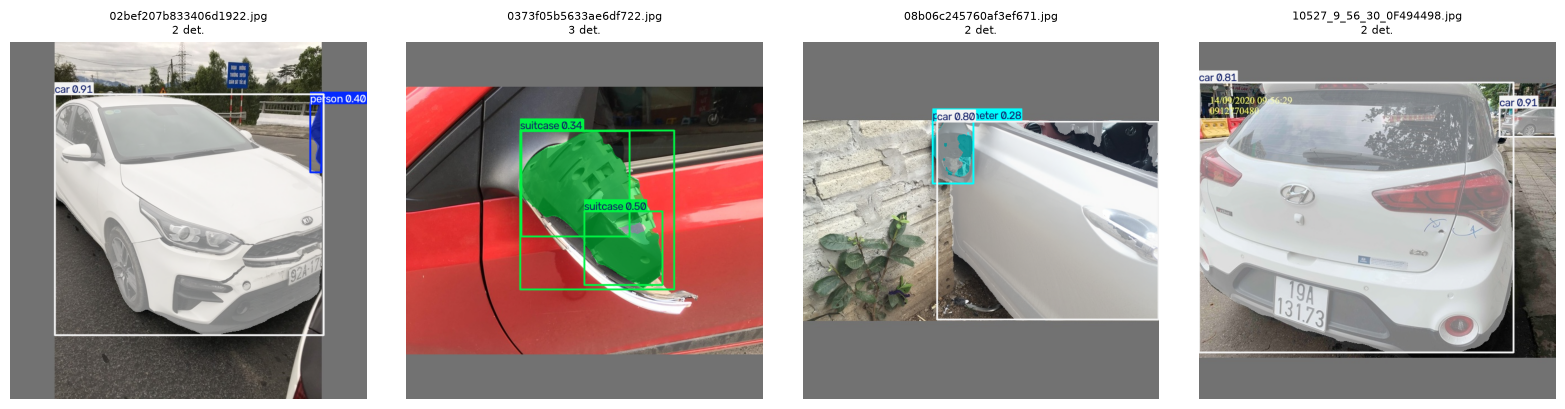

In [5]:
import matplotlib.pyplot as plt

test_images = sorted((REPO_ROOT / "data" / "vehide" / "images" / "test").glob("*.jpg"))[:4]
seg_model = loaded["yolo11n-seg.pt"]

fig, axes = plt.subplots(1, len(test_images), figsize=(16, 4))
for ax, img_path in zip(axes, test_images):
    result = seg_model.predict(img_path, imgsz=640, device="cpu", verbose=False)[0]
    ax.imshow(result.plot()[..., ::-1])  # BGR -> RGB
    ax.set_title(f"{img_path.name}\n{len(result.boxes)} det.", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [6]:
r = seg_model.predict(test_images[0], imgsz=640, device="cpu", verbose=False)[0]
print("Output object:", type(r))
print("boxes.xywhn shape:", r.boxes.xywhn.shape if r.boxes is not None else None)
print("masks shape:", r.masks.data.shape if r.masks is not None else "no masks returned")
if len(r.boxes):
    b = r.boxes[0]
    print("Example detection -> class:", r.names[int(b.cls)], "| conf:", float(b.conf),
          "| xywhn:", b.xywhn[0].tolist())
else:
    print("No detections above the default confidence threshold on this image.")


Output object: <class 'ultralytics.engine.results.Results'>
boxes.xywhn shape: torch.Size([2, 4])
masks shape: torch.Size([2, 640, 640])
Example detection -> class: car | conf: 0.911323606967926 | xywhn: [0.5023953914642334, 0.4835977554321289, 0.7544678449630737, 0.6745426058769226]


## 5. Small-scale end-to-end pipeline check: does fine-tuning actually wire together?

Milestone 3 requires "a small scale pipeline passing a subset of the dataset through the full
workflow ... to verify that all components of the pipeline work together correctly." The most
direct real test of that is a 1-epoch fine-tune against `data/damage.yaml`, using the sample
train/val images already committed in the repo.

Before running it: `scripts/yolo_schema.py`'s docstring already flags that
`data/vehide/labels/` holds plain 5-field bounding boxes (`class x_center y_center width
height`), not the variable-length polygon format YOLO's segmentation trainer expects. Confirmed
directly here rather than taken on faith.


In [7]:
sample_label = next((REPO_ROOT / "data" / "vehide" / "labels" / "train").glob("*.txt"))
lines = sample_label.read_text().strip().splitlines()
print(sample_label.name)
for line in lines[:3]:
    print(" fields:", len(line.split()), "->", line)


03bda226ad62553c0c73.txt
 fields: 5 -> 1 0.257422 0.187500 0.217969 0.372917
 fields: 5 -> 0 0.473828 0.385937 0.189844 0.157292
 fields: 5 -> 1 0.393750 0.307812 0.128125 0.059375


Confirmed: every label file is 5 fields per line (`class, x_center, y_center, width, height`)
— **detection**-format labels, not segmentation polygons. The next two cells show the
consequence directly: first attempting to fine-tune the **-seg** variant Milestone 3 currently
specifies against this data, then the plain **detection** variant, which actually matches
what's on disk.

One more pre-existing issue has to be worked around first: `data/damage.yaml`'s `path:` field
points at `./vehide_processed`, a directory that does not exist anywhere in this repo — the
sample images/labels actually committed live under `data/vehide/`. Rather than edit the tracked
config file, the next cell builds a corrected copy of the same dataset config (same `nc`,
`names`, split layout) pointed at the real path, written only to the scratch artifacts
directory, and uses that for the smoke-test training runs below.


In [8]:
fixed_data_yaml = ARTIFACTS_DIR / "damage_fixed_path.yaml"
fixed_data_yaml.write_text(yaml.dump({
    "path": str(REPO_ROOT / "data" / "vehide"),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": damage_yaml["nc"],
    "names": damage_yaml["names"],
}))
print("Wrote corrected dataset config (path fixed, everything else unchanged):")
print(fixed_data_yaml.read_text())


Wrote corrected dataset config (path fixed, everything else unchanged):
names:
- dent
- scratch
- crack
- broken_lamp
- shattered_glass
- flat_tyre
nc: 6
path: C:\Users\acer\OneDrive\Documents\DataScience&AILabProj\Group-1-DS-and-AI-Lab-Project\data\vehide
test: images/test
train: images/train
val: images/val



In [9]:
seg_train_model = YOLO(str(ARTIFACTS_DIR / "yolo11n-seg.pt"))
try:
    seg_train_model.train(
        data=str(fixed_data_yaml),
        epochs=1,
        imgsz=320,
        batch=2,
        device="cpu",
        workers=0,
        project=str(ARTIFACTS_DIR / "runs"),
        name="seg_smoke_test",
        exist_ok=True,
        verbose=False,
        plots=False,
    )
    print("\nRESULT: YOLO11n-seg training on the current bbox-only labels SUCCEEDED.")
except Exception as e:
    print(f"\nRESULT: YOLO11n-seg training on the current bbox-only labels FAILED "
          f"({type(e).__name__}): {e}")


Ultralytics 8.4.104  Python-3.14.4 torch-2.13.0+cpu CPU (AMD Ryzen 5 3500U with Radeon Vega Mobile Gfx)


engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\acer\AppData\Local\Temp\damage_yolo11_analysis\damage_fixed_path.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Users\acer\AppData\Local\Temp\damage_yolo11_analysis\yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=seg_smoke_test, nbs=64, nms=

Overriding model.yaml nc=80 with nc=6



                   from  n    params  module                                       arguments                     


  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 


...

Transferred 510/561 items from pretrained weights


Freezing layer 'model.23.dfl.conv.weight'


train: Fast image access  (ping: 0.80.1 ms, read: 93.924.3 MB/s, size: 124.1 KB)


train: Scanning C:\Users\acer\OneDrive\Documents\DataScience&AILabProj\Group-1-DS-and-AI-Lab-Project\data\vehide\labels\train.cache... 9 images, 15 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 24/24 45.7Kit/s 0.0s


RESULT: YOLO11n-seg training on the current bbox-only labels FAILED (ValueError): Segment dataset requires equal numbers of boxes and segments, but got len(segments) = 0, len(boxes) = 37. Please supply a segment dataset, not a detect dataset.


In [10]:
det_model = YOLO(str(ARTIFACTS_DIR / "yolo11n.pt"))
det_results = det_model.train(
    data=str(fixed_data_yaml),
    epochs=1,
    imgsz=320,
    batch=2,
    device="cpu",
    workers=0,
    project=str(ARTIFACTS_DIR / "runs"),
    name="det_smoke_test",
    exist_ok=True,
    verbose=False,
    plots=False,
    cls=2.0,  # matches the partial inverse-frequency class weighting documented in M2/M3
)
print("\nSmoke-test training completed. Final-epoch metrics:")
for k, v in det_results.results_dict.items():
    print(f"  {k}: {v}")


Ultralytics 8.4.104  Python-3.14.4 torch-2.13.0+cpu CPU (AMD Ryzen 5 3500U with Radeon Vega Mobile Gfx)


engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.0, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\acer\AppData\Local\Temp\damage_yolo11_analysis\damage_fixed_path.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Users\acer\AppData\Local\Temp\damage_yolo11_analysis\yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=det_smoke_test, nbs=64, nms=Fals

Overriding model.yaml nc=80 with nc=6



                   from  n    params  module                                       arguments                     


  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 83% ━━━━━━━━━━── 5/6 1.3it/s 3.2s<0.8s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.5it/s 4.0s

                   all         24         33   0.000202        0.2     0.0111    0.00442


Speed: 1.9ms preprocess, 147.0ms inference, 0.0ms loss, 3.5ms postprocess per image



Smoke-test training completed. Final-epoch metrics:
  metrics/precision(B): 0.00020242914979757084
  metrics/recall(B): 0.2
  metrics/mAP50(B): 0.011055555555555555
  metrics/mAP50-95(B): 0.0044222222222222215
  fitness: 0.0044222222222222215


Checkpoint: C:\Users\acer\AppData\Local\Temp\damage_yolo11_analysis\runs\det_smoke_test\weights\best.pt
Classes the fine-tuned checkpoint predicts: {0: 'dent', 1: 'scratch', 2: 'crack', 3: 'broken_lamp', 4: 'shattered_glass', 5: 'flat_tyre'}
Detections on 10c48e02012020_150813image493888.jpg : 0


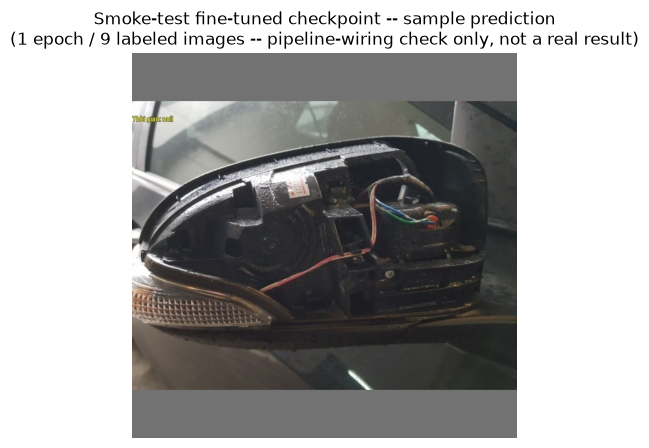

In [11]:
best_ckpt = Path(det_model.trainer.save_dir) / "weights" / "best.pt"
smoke_model = YOLO(str(best_ckpt))
val_image = next((REPO_ROOT / "data" / "vehide" / "images" / "val").glob("*.jpg"))
r2 = smoke_model.predict(val_image, imgsz=320, device="cpu", verbose=False)[0]

print("Checkpoint:", best_ckpt)
print("Classes the fine-tuned checkpoint predicts:", r2.names)
print("Detections on", val_image.name, ":", len(r2.boxes))

plt.figure(figsize=(5, 5))
plt.imshow(r2.plot()[..., ::-1])
plt.axis("off")
plt.title("Smoke-test fine-tuned checkpoint -- sample prediction\n"
          "(1 epoch / 9 labeled images -- pipeline-wiring check only, not a real result)")
plt.show()


## 6. Summary

**Architecture (§2, real numbers, not estimated):**

| | YOLO11n-seg | YOLO11m-seg |
|---|---|---|
| Layers | 203 | 253 |
| Parameters | 2,876,848 | 22,420,896 |
| GFLOPs | 9.9 | 113.9 |

**CPU inference latency (§3, this machine, no CUDA GPU -- integrated AMD graphics):**

| Variant | imgsz | ms/image |
|---|---|---|
| YOLO11n-seg | 640 | 704 |
| YOLO11n-seg | 1280 | 2,310 |
| YOLO11m-seg | 640 | 2,930 |
| YOLO11m-seg | 1280 | **9,955** |

YOLO11m-seg at the project's chosen 1280px training resolution (Milestone 3 Section 7) takes
**~10 seconds/image on CPU**. That is the number to weigh against the "CPU-basic Hugging Face
Spaces" deployment target in Section 2.6/Section 12 -- it is not interactive at that size on
CPU-class hardware. The forward pass itself works correctly (Section 4): COCO-pretrained
YOLO11n-seg returned proper boxes + `[N, 640, 640]` instance masks on the project's own sample
photos.

**Small-scale pipeline check (§5) -- the key finding:**

Fine-tuning **YOLO11n-seg** (the segmentation variant Milestone 3 currently specifies) against
the sample data failed with a real, reproducible error, not a hypothetical one:

> `ValueError: Segment dataset requires equal numbers of boxes and segments, but got
> len(segments) = 0, len(boxes) = 37. Please supply a segment dataset, not a detect dataset.`

This confirms directly (not just from `scripts/yolo_schema.py`'s comment) that
`data/vehide/labels/` contains plain detection boxes, not segmentation polygons -- the
**-seg** architecture Milestone 3 Section 4.1 selects cannot train on the data as currently
exported by `scripts/preprocess_images.py`.

Switching to the plain **detection** variant (YOLO11n, no `-seg`) against the same labels and
same `data/damage.yaml` taxonomy succeeded end-to-end: 1 epoch over the 24-image sample trained
without error, produced a 6-class checkpoint (`{0: dent, 1: scratch, 2: crack, 3: broken_lamp,
4: shattered_glass, 5: flat_tyre}`), and that checkpoint loaded and ran inference on a held-out
val image. Metrics from this smoke test (mAP50 = 0.011, precision = 0.0002) are meaningless by
construction -- 1 epoch on 9 labeled images -- and are not a substitute for the real Milestone 4
training run; the point of this cell was pipeline wiring, not performance.

A second, unrelated pre-existing issue was also hit and worked around (not fixed in the repo):
`data/damage.yaml`'s `path: ./vehide_processed` points at a directory that does not exist --
the actual committed sample data lives under `data/vehide/`. The notebook builds a corrected
copy of the same config in a scratch directory rather than editing the tracked file.

**Bottom line -- can YOLO11 be used in this project?** Yes, the architecture loads, runs
inference, and fine-tunes correctly, and Ultralytics' full toolchain (training, checkpointing,
metrics) works on Python 3.14 / CPU-only in this environment with no compatibility issues. But
two concrete gaps need a decision before Milestone 4, both written up in the chat response:
(1) the **-seg** vs plain-**detection** mismatch between the committed labels and the
architecture Milestone 3 currently specifies, and (2) the CPU inference latency at 1280px is
too slow for an interactive CPU-only demo as currently scoped.
